### **Nombre: Luis Lema**

### **Curso: GR1CCC**

### **Fecha: 30/01/2026**

## **Splines cúbicos**

In [4]:
def Spline(x: float, x0: float, pars: dict[str, float]) -> float:
    a = pars["a"]
    b = pars["b"]
    c = pars["c"]
    d = pars["d"]
    return a + b * (x - x0) + c * (x - x0) ** 2 + d * (x - x0) ** 3

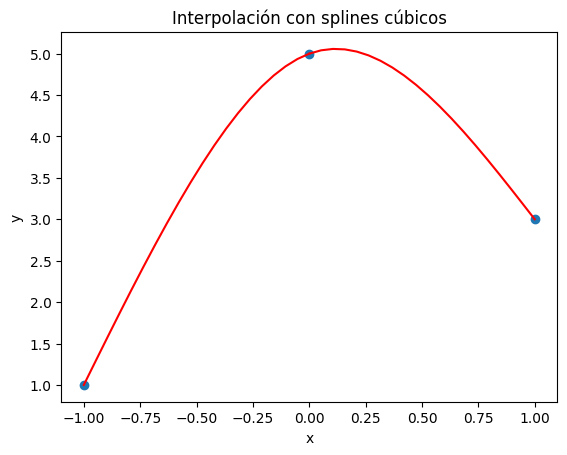

In [5]:
import matplotlib.pyplot as plt
import numpy as np

xs = [-1, 0, 1]
ys = [1, 5, 3]
s = [
    {"a": 1, "b": 5.5, "c": 0, "d": -1.5},
    {"a": 5, "b": 1, "c": -4.5, "d": 1.5},
]
for i, x_i in enumerate(xs[:-1]):
    _x = np.linspace(x_i, xs[i + 1], 20)
    _y = Spline(_x, x_i, s[i])
    plt.plot(_x, _y, color="red")

plt.scatter(xs, ys)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolación con splines cúbicos")
plt.show()

## Tarea

Grafique los splines cúbicos tal que cumplan con la pendiente -2 deseada en el punto (x1,y1)


S0(x) = 1 + 12.8571(x+1) + -2.0000(x+1)^2 + 1.0000(x+1)^3
S1(x) = 5 + -7.7143x + 3.1429x^2 + 5.0000x^3


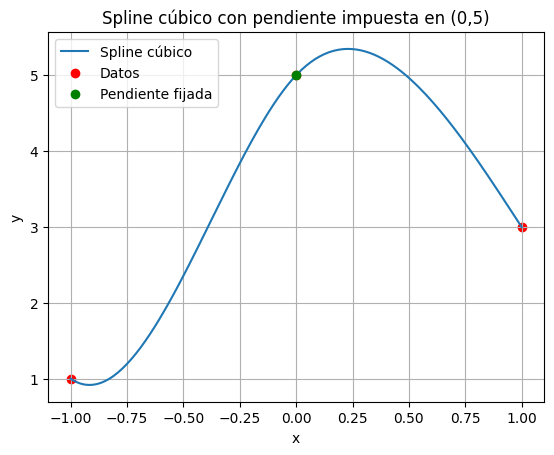

In [ ]:
import numpy as np
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt

# Datos
x = np.array([-1, 0, 1])
y = np.array([1, 5, 3])

# Punto donde se fija la pendiente
x1 = 0
y1 = 5
m = -2     

# Condiciones:
# derivada en x1 y natural al final
cs = CubicSpline(x, y, bc_type=((1, m), (2, 0)))

# Coeficientes
coeffs = cs.c

# Spline en [-1,0]
a0, b0, c0, d0 = coeffs[:, 0]
S0 = f"{y[0]} + {b0:.4f}(x+1) + {c0:.4f}(x+1)^2 + {d0:.4f}(x+1)^3"

# Spline en [0,1]
a1, b1, c1, d1 = coeffs[:, 1]
S1 = f"{y[1]} + {b1:.4f}x + {c1:.4f}x^2 + {d1:.4f}x^3"

print("S0(x) =", S0)
print("S1(x) =", S1)

# Gráfica
xg = np.linspace(-1, 1, 200)
yg = cs(xg)

plt.plot(xg, yg, label="Spline cúbico")
plt.scatter(x, y, color="red", label="Datos")
plt.scatter(x1, y1, color="green", zorder=5, label="Pendiente fijada")
plt.title("Spline cúbico con pendiente impuesta en (0,5)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
